In [2]:
from collections import Counter, defaultdict
from scipy.spatial import distance
import matplotlib.pyplot as plt
from rdkit import Chem
import numpy as np
import pandas as pd
from tqdm import tqdm
import pickle
import os
import tarfile
import pymol
from pymol import cmd
import matplotlib.image as mpimg

In [3]:
DOCKING_RESULTS_REAL_2 = {}
DOCKING_RESULTS_ORIGINAL = {}

# Define some paths
root = '../../../Documents_GPU/mtb-targeted-protein-degradation/notebooks'
PATH_TO_DOCKING_RESULTS_ORIGINAL = os.path.join(root, "..", "processed", "unidock_docking", 'docking_results')
PATH_TO_DOCKING_RESULTS_REAL_2 = os.path.join(root, "..", "processed", "unidock_REAL_docking_2", 'docking_results')

# Mapping IDs to SMILES
ID_TO_SMILES = pickle.load(open(os.path.join(root, "..", "processed", "enamine_characterization", "ID_TO_SMI.pkl"), "rb"))

# Load pocket detection data
pocket_detection_data = pd.read_csv(os.path.join(root, "..", "processed", "pocket_detection_data.csv"))

# Load pocket coordinates
pocket_to_coords = {}
for file, pocket_numb, coord in zip(pocket_detection_data['File name'], pocket_detection_data['Pocket number'], pocket_detection_data['Pocket centroid coordinate (x y z)']):
    label = file.replace(".pdb", "") + "_pocket_" + str(pocket_numb)
    pocket_to_coords[label] = np.array(coord.split(), dtype=float)

# For each pocket - REAL 2
for pocket in tqdm(sorted(os.listdir(PATH_TO_DOCKING_RESULTS_REAL_2))):
    try:
        scores = pd.read_csv(os.path.join(PATH_TO_DOCKING_RESULTS_REAL_2, pocket, 'report.csv'))
        if len(scores) == 99105:
            DOCKING_RESULTS_REAL_2[pocket] = {i: j for i, j in zip(scores['compound'], scores['score'])}
        else:
            print(pocket, len(scores))
    except:
        pass

# For each pocket - ORIGINAL
for pocket in tqdm(sorted(os.listdir(PATH_TO_DOCKING_RESULTS_ORIGINAL))):
    scores = pd.read_csv(os.path.join(PATH_TO_DOCKING_RESULTS_ORIGINAL, pocket, 'report.csv'))
    DOCKING_RESULTS_ORIGINAL[pocket] = {i: j for i, j in zip(scores['compound'], scores['score'])}

 21%|██        | 24/113 [00:01<00:04, 20.67it/s]

 48%|████▊     | 54/113 [00:02<00:02, 21.36it/s]

alphafold3_P9WFT3_model_3_pocket_2 24635
alphafold3_P9WFT5_model_1_pocket_2 0
alphafold3_P9WFT5_model_2_pocket_1 53049


 55%|█████▍    | 62/113 [00:02<00:01, 27.37it/s]

alphafold3_P9WFT7_model_1_pocket_2 0
alphafold3_P9WFT7_model_2_pocket_2 0
alphafold3_P9WFT9_model_3_pocket_2 0
alphafold3_P9WFT9_model_4_pocket_2 0


...

 93%|█████████▎| 105/113 [00:04<00:00, 21.47it/s]

chai1_P9WFU9_model_1_pocket_2 0


100%|██████████| 113/113 [00:04<00:00, 23.09it/s]


swissmodel_P9WFU5_model_0_pocket_2 0
swissmodel_P9WFU9_model_0_pocket_1 7040
swissmodel_P9WFV5_model_0_pocket_2 0


100%|██████████| 276/276 [00:08<00:00, 30.86it/s]


In [4]:
# Define pockets and compounds
POCKETS = sorted(DOCKING_RESULTS_ORIGINAL)
COMPOUNDS = sorted(DOCKING_RESULTS_ORIGINAL[POCKETS[0]])

print(f"Number of pockets: {len(POCKETS)}")
print(f"Number of compounds: {len(COMPOUNDS)}")

scores = [DOCKING_RESULTS_ORIGINAL[pocket][compound] for pocket in POCKETS for compound in COMPOUNDS]
print(f"Average score: {round(np.average(scores), 3)}")
print(f"Percentile 25: {round(np.percentile(scores, 25), 3)}")
print(f"Percentile 5: {round(np.percentile(scores, 5), 3)}")
print(f"Percentile 1: {round(np.percentile(scores, 1), 3)}")
print(f"Percentile 0.1: {round(np.percentile(scores, 0.1), 3)}")
del scores

Number of pockets: 276
Number of compounds: 100154
Average score: -5.223


Percentile 25: -7.311
Percentile 5: -8.341
Percentile 1: -9.138
Percentile 0.1: -10.111


In [5]:
cpd_to_pockets = {}
cpd_to_proteins = {}
pocket_to_cpds = {}
protein_to_cpds = {}

SCORES = [-7, -8, -9, -10, -11]

for SCORE in SCORES:

    cpd_to_pockets[SCORE] = defaultdict(dict)
    cpd_to_proteins[SCORE] = defaultdict(dict)
    pocket_to_cpds[SCORE] = defaultdict(set)
    protein_to_cpds[SCORE] = defaultdict(set)

    for compound in tqdm(COMPOUNDS):
        pockets = set([pocket for pocket in POCKETS if DOCKING_RESULTS_ORIGINAL[pocket][compound] < SCORE])
        proteins = set([pocket.split("_")[1] for pocket in pockets])
        cpd_to_pockets[SCORE][compound] = pockets
        cpd_to_proteins[SCORE][compound] = proteins
        for pocket in pockets:
            pocket_to_cpds[SCORE][pocket].add(compound)
        for protein in proteins:
            protein_to_cpds[SCORE][protein].add(compound)

100%|██████████| 100154/100154 [00:07<00:00, 12666.61it/s]


In [6]:
hits = [1] + [i for i in range(10, 100_000, 10)]
y_pockets = {}
y_proteins = {}
for score in SCORES:
    y_pockets[score] = list()
    y_proteins[score] = list()
    for N in hits:
        # print(f"Number of pockets with {N}+ hits: {len([i for i in pocket_to_cpds[score] if len(pocket_to_cpds[score][i]) > N])}")
        y_pockets[score].append(len([i for i in pocket_to_cpds[score] if len(pocket_to_cpds[score][i]) > N]))
        y_proteins[score].append(len([i for i in protein_to_cpds[score] if len(protein_to_cpds[score][i]) > N]))

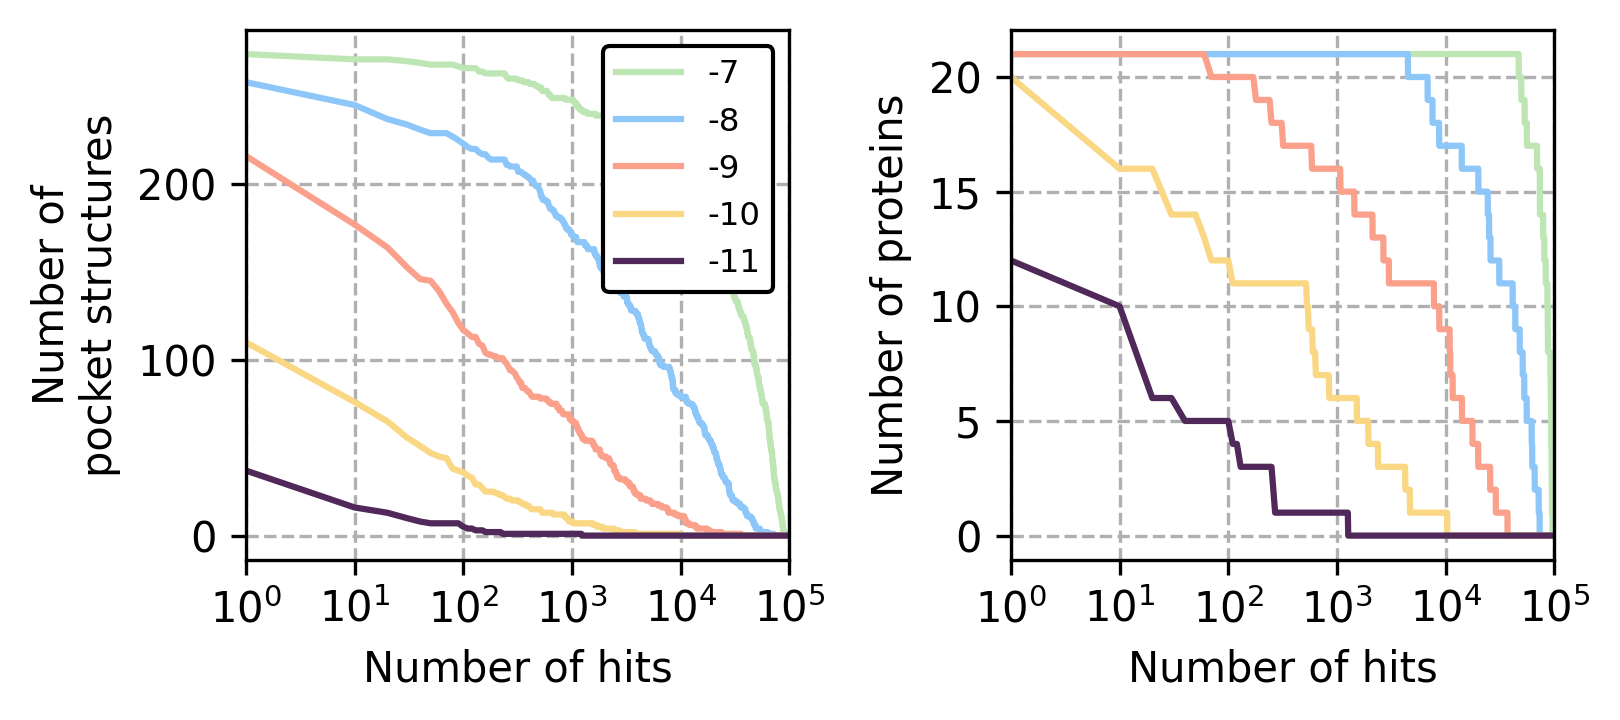

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(5.5, 2.5), dpi=300)

COLORS= ['#50285A', '#FAD782', '#FAA08B', '#8DC7FA', '#BEE6B4'][::-1]
for score, color in zip(SCORES, COLORS):
    ax[0].plot(hits, y_pockets[score], label=str(score), c=color)
for score, color in zip(SCORES, COLORS):
    ax[1].plot(hits, y_proteins[score], label=str(score), c=color)


ax[0].grid(linestyle='--', zorder=-2)
ax[0].set_ylabel("Number of\npocket structures")
ax[0].set_xlabel("Number of hits")
ax[0].legend(loc='upper right', framealpha=1, edgecolor='k', prop={'size': 7.8})
ax[0].set_xscale('log')
ax[0].set_xlim([1, 100_000])
ax[0].set_xticks([10**0, 10**1, 10**2, 10**3, 10**4, 10**5])

ax[1].grid(linestyle='--', zorder=-2)
ax[1].set_xlabel("Number of hits")
ax[1].set_ylabel("Number of proteins")
ax[1].set_xscale('log')
ax[1].set_xlim([1, 100_000])
ax[1].set_xticks([10**0, 10**1, 10**2, 10**3, 10**4, 10**5])

plt.tight_layout()
plt.show()

In [8]:
print(f"Pocket structures with 100+ hits at score cut-off -10: {y_pockets[-10][np.where(np.array(hits) == 100)[0][0]]}")
print(f"Pocket structures with 1000+ hits at score cut-off -9: {y_pockets[-9][np.where(np.array(hits) == 1000)[0][0]]}")
print(f"Proteins with 100+ hits at score cut-off -10: {y_proteins[-10][np.where(np.array(hits) == 100)[0][0]]}")
print(f"Proteins with 1000+ hits at score cut-off -9: {y_proteins[-9][np.where(np.array(hits) == 1000)[0][0]]}")

Pocket structures with 100+ hits at score cut-off -10: 36
Pocket structures with 1000+ hits at score cut-off -9: 65
Proteins with 100+ hits at score cut-off -10: 12
Proteins with 1000+ hits at score cut-off -9: 16


In [9]:
POCKET_PAIRS = set([tuple(sorted([i,j])) for i in POCKETS for j in POCKETS if i != j])
RESULTS = []
for pocket1, pocket2 in POCKET_PAIRS:
    protein1 = pocket1.split("_")[1]
    protein2 = pocket2.split("_")[1]
    same_protein = protein1 == protein2
    same_pocket = False
    if same_protein == True:
        d = distance.euclidean(pocket_to_coords[pocket1], pocket_to_coords[pocket2])
        if d < 6.14:
            same_pocket = True
    intersection = []
    for score in SCORES:
        cpds1 = pocket_to_cpds[score][pocket1]
        cpds2 = pocket_to_cpds[score][pocket2]
        intersection.append(len(cpds1.intersection(cpds2)))
    RESULTS.append([pocket1, pocket2, same_protein, same_pocket] + intersection)
RESULTS = pd.DataFrame(RESULTS, columns=["pocket1", "pocket2", "same_protein", "same_pocket"] + SCORES)

print(f"Number of pairs: {len(RESULTS)}")
print(f"Same pocket: {len(RESULTS[RESULTS['same_pocket'] == True])}")
print(f"Same protein: {len(RESULTS[(RESULTS['same_pocket'] == False) & (RESULTS['same_protein'] == True)])}")
print(f"Different protein: {len(RESULTS[RESULTS['same_protein'] == False])}")

Number of pairs: 37950
Same pocket: 738
Same protein: 1639
Different protein: 35573


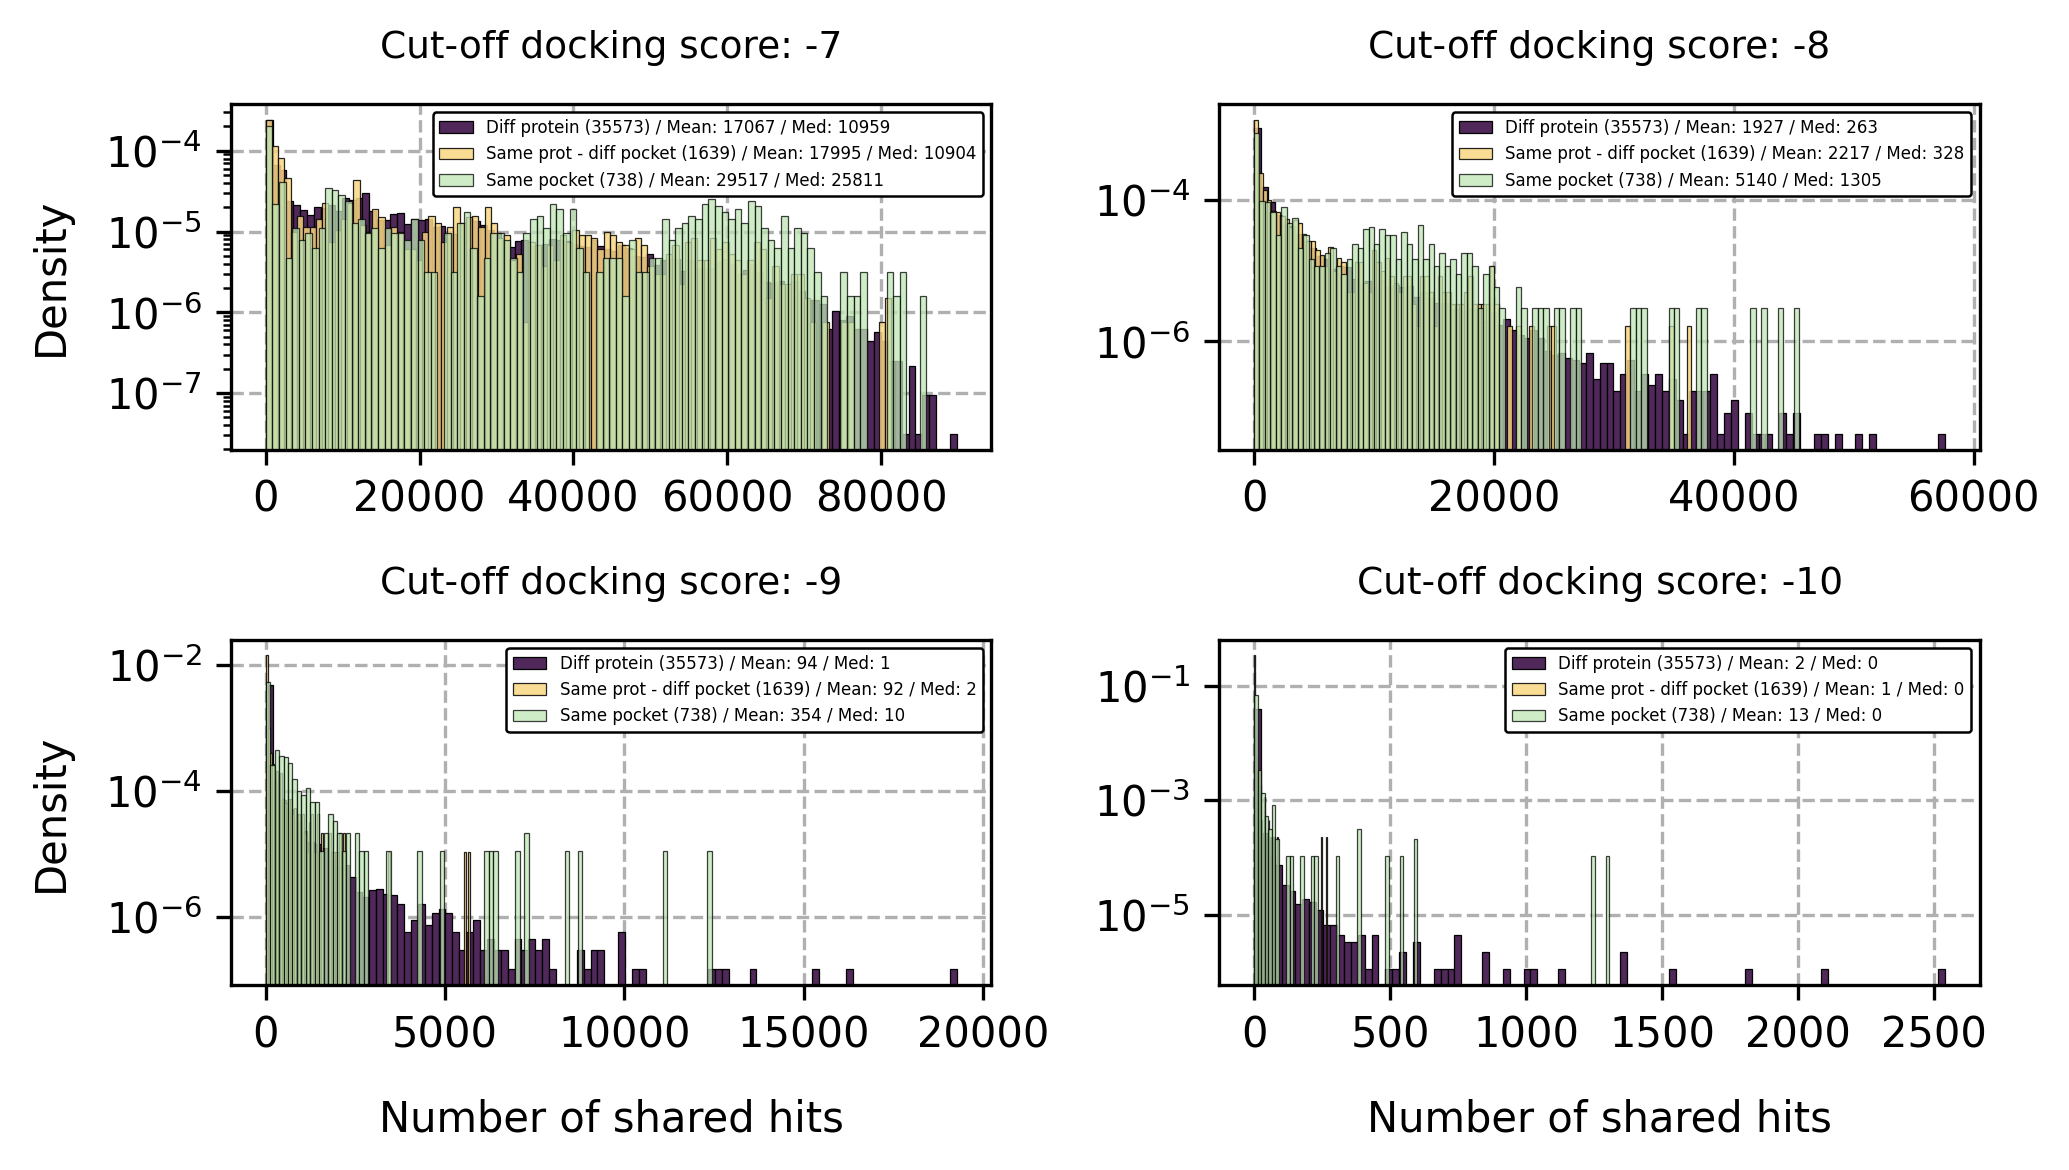

In [10]:
fig, ax = plt.subplots(2, 2, figsize=(7, 4), dpi=300)

for (c1, c2), score in zip([[0,0], [0,1], [1,0], [1,1]], [-7, -8, -9, -10]):

    h1 = RESULTS[RESULTS['same_protein'] == False][score].tolist()
    h2 = RESULTS[(RESULTS['same_protein'] == True) & (RESULTS['same_pocket'] == False)][score].tolist()
    h3 = RESULTS[RESULTS['same_pocket'] == True][score].tolist()

    label1 = f'Diff protein ({len(h1)}) / Mean: {int(np.mean(h1))} / Med: {int(np.median(h1))}'
    label2 = f'Same prot - diff pocket ({len(h2)}) / Mean: {int(np.mean(h2))} / Med: {int(np.median(h2))}'
    label3 = f'Same pocket ({len(h3)}) / Mean: {int(np.mean(h3))} / Med: {int(np.median(h3))}'

    # bins = [i for i in range(0, 100_000, 100)]
    ax[c1][c2].hist(h1, bins=100, density=True, color="#50285A", label=label1, linewidth=0.3, edgecolor='k', zorder=2)
    ax[c1][c2].hist(h2, bins=100, density=True, color="#FAD782", alpha=0.85, label=label2, linewidth=0.3, edgecolor='k', zorder=2)
    ax[c1][c2].hist(h3, bins=100, density=True, color="#BEE6B4", alpha=0.75, label=label3, linewidth=0.3, edgecolor='k', zorder=2)

    l = ax[c1][c2].legend(framealpha=1, edgecolor='k', prop={'size': 4})
    l.get_frame().set_linewidth(0.6)

    ax[c1][c2].set_yscale('log')
    ax[c1][c2].set_title(f"Cut-off docking score: {score}", pad=11, size=9)
    if c1 == 1:
        ax[c1][c2].set_xlabel("Number of shared hits", labelpad=10)
    if c2 == 0:
        ax[c1][c2].set_ylabel("Density", labelpad=8)
    ax[c1][c2].grid(linestyle='--', zorder=-2)

plt.tight_layout()
plt.show()

In [11]:
n_structures = [i for i in range(1, len(POCKETS)+1, 1)]
n_proteins = [i for i in range(1, len(set([i.split("_")[1] for i in POCKETS]))+1, 1)]
y_pockets = {}
y_proteins = {}
for score in SCORES:
    y_pockets[score] = list()
    y_proteins[score] = list()
    for N in n_structures:
        y_pockets[score].append(len([i for i in cpd_to_pockets[score] if len(cpd_to_pockets[score][i]) > N]))
    for N in n_proteins:
        y_proteins[score].append(len([i for i in cpd_to_proteins[score] if len(cpd_to_proteins[score][i]) > N ]))

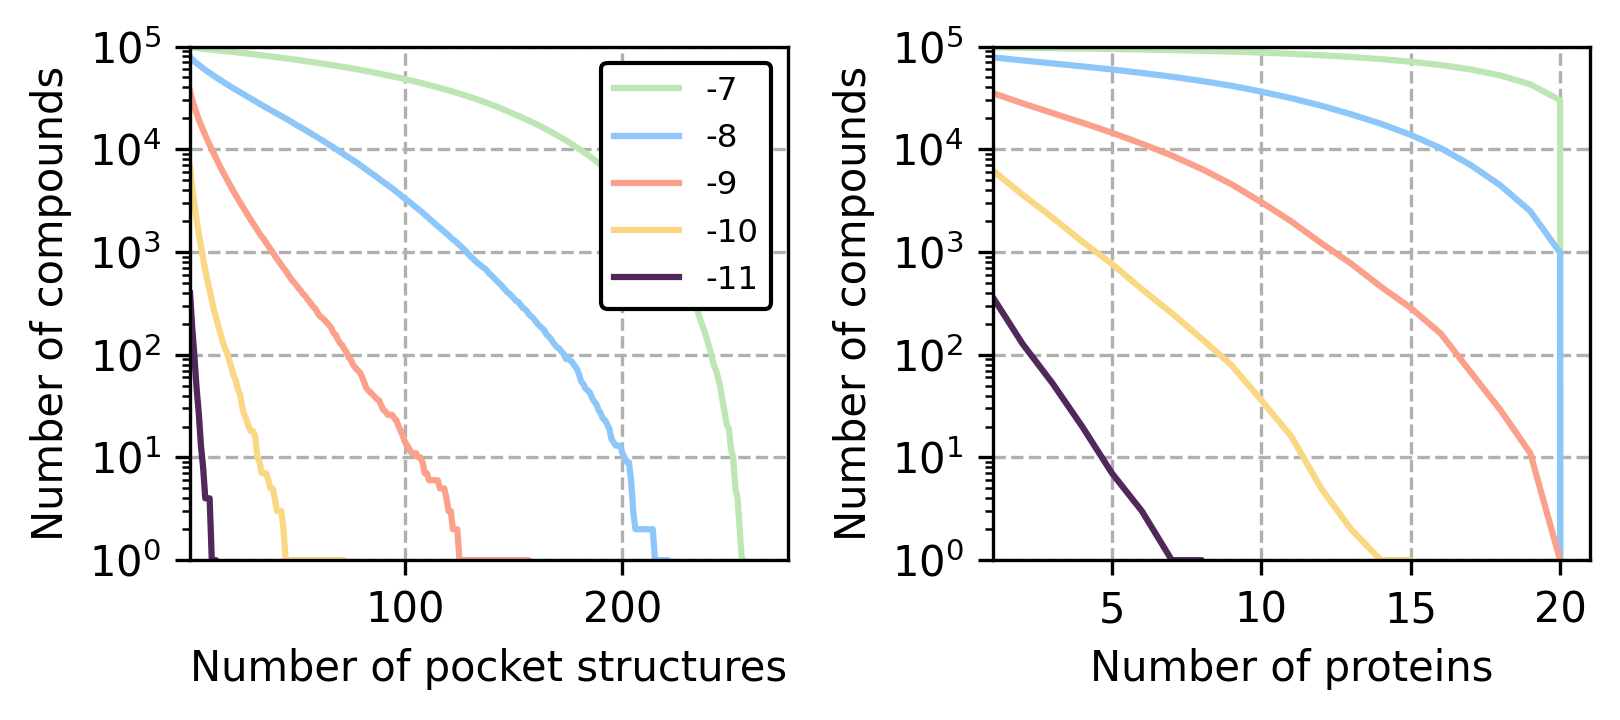

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(5.5, 2.5), dpi=300)

COLORS= ['#50285A', '#FAD782', '#FAA08B', '#8DC7FA', '#BEE6B4'][::-1]
for score, color in zip(SCORES, COLORS):
    ax[0].plot(n_structures, y_pockets[score], label=str(score), c=color)
for score, color in zip(SCORES, COLORS):
    ax[1].plot(n_proteins, y_proteins[score], label=str(score), c=color)


ax[0].grid(linestyle='--', zorder=-2)
ax[0].set_xlabel("Number of pocket structures")
ax[0].set_ylabel("Number of compounds")
ax[0].legend(loc='upper right', framealpha=1, edgecolor='k', prop={'size': 7.8})
ax[0].set_yscale('log')
ax[0].set_ylim([1, 100_000])
ax[0].set_xlim([1, 276])
ax[0].set_yticks([10**0, 10**1, 10**2, 10**3, 10**4, 10**5])

ax[1].grid(linestyle='--', zorder=-2)
ax[1].set_ylabel("Number of compounds")
ax[1].set_xlabel("Number of proteins")
ax[1].set_yscale('log')
ax[1].set_ylim([1, 100_000])
ax[1].set_xlim([1, 21])
ax[1].set_yticks([10**0, 10**1, 10**2, 10**3, 10**4, 10**5])

plt.tight_layout()
plt.show()

In [13]:
print(f"Compounds with 10+ pocket_structures at score cut-off -10: {y_pockets[-10][np.where(np.array(n_structures) == 10)[0][0]]}")
print(f"Compounds with 100+ pocket_structures at score cut-off -9: {y_pockets[-9][np.where(np.array(n_structures) == 100)[0][0]]}")
print(f"Compounds with 10+ proteins at score cut-off -10: {y_proteins[-10][np.where(np.array(n_proteins) == 10)[0][0]]}")
print(f"Compounds with 10+ proteins at score cut-off -9: {y_proteins[-9][np.where(np.array(n_proteins) == 10)[0][0]]}")
print(f"Compounds with 2+ proteins at score cut-off -11: {y_proteins[-11][np.where(np.array(n_proteins) == 2)[0][0]]}")
print(f"Compounds with 5+ proteins at score cut-off -11: {y_proteins[-11][np.where(np.array(n_proteins) == 5)[0][0]]}")

Compounds with 10+ pocket_structures at score cut-off -10: 423
Compounds with 100+ pocket_structures at score cut-off -9: 14
Compounds with 10+ proteins at score cut-off -10: 36
Compounds with 10+ proteins at score cut-off -9: 3050
Compounds with 2+ proteins at score cut-off -11: 128
Compounds with 5+ proteins at score cut-off -11: 7


In [14]:
from rdkit.Chem import Draw
from IPython.display import display

def grid(mols, per_row=6, legends=None, size=(200,200), svg=False):
    if legends is None: legends = [""]*len(mols)
    img = Draw.MolsToGridImage(mols, molsPerRow=per_row, subImgSize=size,
                              legends=legends, useSVG=svg, maxMols=1_000)
    display(img)

In [15]:
# compounds = [i for i in cpd_to_proteins[-11] if len(cpd_to_proteins[-11][i]) > 2]
compounds = [i for i in cpd_to_proteins[-11] if len(cpd_to_proteins[-11][i]) > 5]
compounds = [Chem.MolFromSmiles(ID_TO_SMILES[i]) for i in compounds]
len(compounds)

7

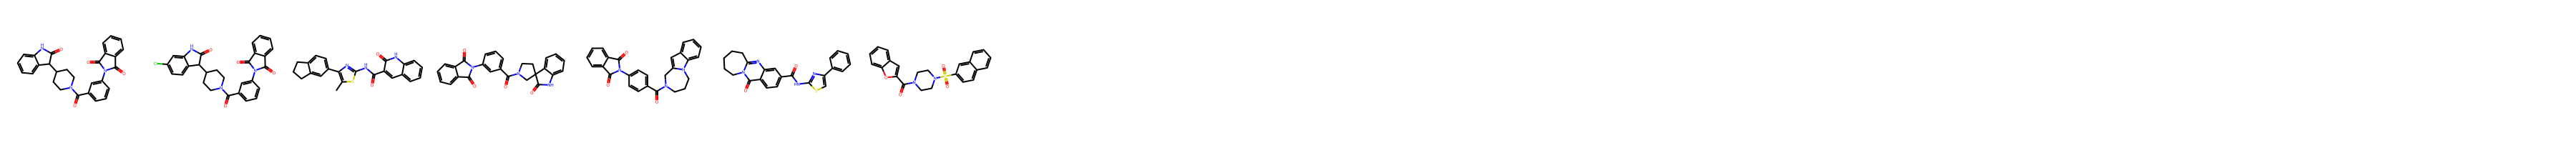

In [16]:
grid(compounds, per_row=18)

In [17]:
compounds = [i for i in cpd_to_proteins[-11] if len(cpd_to_proteins[-11][i]) > 5]
compounds

['Z1024049144',
 'Z1070219674',
 'Z1275189362',
 'Z1744517862',
 'Z2156594494',
 'Z27770727',
 'Z29403904']

In [18]:
def pick_pockets(pocket_to_scores, score_cutoff, N=8):
    candidates = [[i, i.split("_")[1], pocket_to_scores[i]] for i in pocket_to_scores if pocket_to_scores[i] < score_cutoff]
    candidates = sorted(candidates, key=lambda x: x[2])
    best_per_protein = {}
    for pocket, protein, score in candidates:
        if protein not in best_per_protein or score < best_per_protein[protein][1]:
            best_per_protein[protein] = [pocket, score]
    top = [i for i in candidates if best_per_protein[i[1]][0] == i[0]]
    rest = [i for i in candidates if best_per_protein[i[1]][0] != i[0]]
    selected = top + rest
    return selected[:N]

def pymol_screenshot(pocket, ligand, path_to_docking, path_to_output):

    # Define paths
    path_to_output = os.path.join(path_to_output, ligand)
    os.makedirs(path_to_output, exist_ok=True)
    path_to_docking = os.path.join(path_to_docking, pocket)
    st = os.path.join(path_to_docking, pocket.split("_pocket_")[0] + ".pdbqt")

    # Pymol initialization
    pymol.finish_launching(['pymol','-cq'])
    cmd.reinitialize()
    cmd.bg_color("white")
    cmd.set("ray_opaque_background", 0)

    # Load structure
    cmd.load(st, "structure")
    cmd.util.cbag("structure")
    cmd.set_color("structure_col", [0x8D/255, 0xC7/255, 0xFA/255])
    cmd.color("structure_col", "structure and elem C")

    # Load compound
    with tarfile.open(os.path.join(path_to_docking, "docking.tar.gz"), "r|gz") as tf:
        for member in tf:
            if member.name == f"docking/{ligand}_out.sdf":
                data = tf.extractfile(member).read()
                break
    tmp_sdf = os.path.join(path_to_docking, f"{ligand}_tmp.sdf")
    with open(tmp_sdf, "w") as f:
        f.write(data.decode("utf-8", errors="replace"))
    lig = f"lig_{ligand}"
    cmd.load(tmp_sdf, lig)
    os.remove(tmp_sdf)
    cmd.util.cbag(lig)
    cmd.set_color("ligC_orange", [0xF5/255, 0xA6/255, 0x3A/255])
    cmd.color("ligC_orange", f"{lig} and elem C")

    cmd.hide("everything", "structure")
    cmd.show("cartoon", "structure")
    cmd.set("cartoon_transparency", 0.4, "structure")
    cmd.select("pocket_atoms", f"(structure within 6 of {lig}) and not solvent")
    cmd.show("lines", "pocket_atoms")
    cmd.show("sticks", lig)   
    cmd.orient(lig)
    cmd.zoom(lig, buffer=6)
    cmd.h_add("structure")
    cmd.h_add(lig)

    pairs = []
    pairs += cmd.find_pairs(f"{lig} and donor",    "pocket_atoms and acceptor", mode=1, cutoff=3.5, angle=45)
    pairs += cmd.find_pairs(f"{lig} and acceptor", "pocket_atoms and donor",    mode=1, cutoff=3.5, angle=45)
    pairs = list(dict.fromkeys(pairs))

    cmd.delete("hbonds")
    for a1, a2 in pairs:
        cmd.distance("hbonds", a1, a2)

    cmd.color("yellow", "hbonds")
    cmd.set("dash_width", 2)
    cmd.hide("labels", "hbonds")
    cmd.hide("everything", "elem H")

    cmd.set("ray_shadows", 0)
    cmd.set("ray_trace_mode", 1)
    cmd.png(os.path.join(path_to_output, f"{ligand}_{pocket}.png"), width=2000, height=2000, dpi=300, ray=1)
    out_pdb = os.path.join(path_to_output, f"{ligand}_{pocket}.pdb")
    cmd.save(out_pdb)
    COMMAND = f"pandamap {out_pdb} --ligand UNK --output {out_pdb.replace('.pdb', '_pandamap.png')}"
    os.system(COMMAND)
    os.remove(out_pdb)

In [19]:
COMPOUND_ID = "Z1024049144"
SCORE_CUTOFF = -11

# Get mol
mol = Chem.MolFromSmiles(ID_TO_SMILES[COMPOUND_ID])

# For that pocket, get mapping pocket to scores
pocket_to_scores = {pocket: DOCKING_RESULTS_ORIGINAL[pocket][COMPOUND_ID] for pocket in POCKETS}

# Order pockets to visualize (smart sorting)
selected = pick_pockets(pocket_to_scores, SCORE_CUTOFF, N=8)

# Create output directory
PATH_TO_OUTPUT = os.path.join(root, "..", "processed", "unidock_REAL_docking_2", "docking_snapshots")

for pocket, protein, score in selected:
    
    pymol_screenshot(pocket, COMPOUND_ID, PATH_TO_DOCKING_RESULTS_ORIGINAL, PATH_TO_OUTPUT)

Detecting interactions...
*** Using IMPROVED detection with stricter filtering ***
Before filtering: 5 total interactions
Calculating solvent accessibility...
Trying DSSP method first...
Error calculating solvent accessibility: 'HybridProtLigMapper' object has no attribute 'estimate_solvent_accessibility'
Falling back to realistic method
Using realistic solvent accessibility calculation...
Total protein atoms: 7847
Interacting residues to check: 16
Marking ('ALA', 213) as solvent accessible (score: 0.90)
Marking ('HIS', 265) as solvent accessible (score: 1.08)
Marking ('THR', 425) as solvent accessible (score: 1.12)
Marking ('MET', 271) as solvent accessible (score: 0.84)
Marking ('ASP', 415) as solvent accessible (score: 1.12)
Marking ('ALA', 212) as solvent accessible (score: 0.90)
Marking ('PHE', 269) as solvent accessible (score: 0.79)
Marking ('GLY', 476) as solvent accessible (score: 1.00)
Marking ('ARG', 481) as solvent accessible (score: 1.03)
Marking ('LYS', 413) as solvent ac

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6), dpi=1200)
axes = axes.ravel()

for ax, (pocket, protein, score) in zip(axes[[1,2,3,4,6,7,8,9]], selected):
    file = os.path.join(PATH_TO_OUTPUT, COMPOUND_ID, f"{COMPOUND_ID}_{pocket}.png")
    ax.imshow(mpimg.imread(file), interpolation='none')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"{protein}\nDocking score: {score}", fontsize=10)

ax = axes[0]
mol_img = Draw.MolToImage(mol, size=(300, 300))
ax.imshow(np.asarray(mol_img))
ax.axis("off")
ax.set_title(f"Compound ID: {COMPOUND_ID}\nEnamine DL HLL-100", fontsize=10)

ax = axes[5]
scores_to_visualize = [-11, -10, -9, -8, -7]
ax.set_xticks([i for i in range(len(scores_to_visualize))], scores_to_visualize)
ax.set_ylim([0, 21])
ax.grid(linestyle='--', zorder=-2)
ax.set_ylabel("Number of protein targets")
ax.set_xlabel("Docking score")
colors = ['#FAD782', '#FAA08B', '#DC9FDC', '#AA96FA', '#8DC7FA', '#BEE6B4']
for c, score in enumerate(scores_to_visualize):
    ax.bar(c, 21, color="#D2D2D2", edgecolor='k', zorder=2)
    ax.bar(c, len(cpd_to_proteins[score][COMPOUND_ID]), color=colors[c], edgecolor='k', zorder=2)

plt.tight_layout()
plt.show()

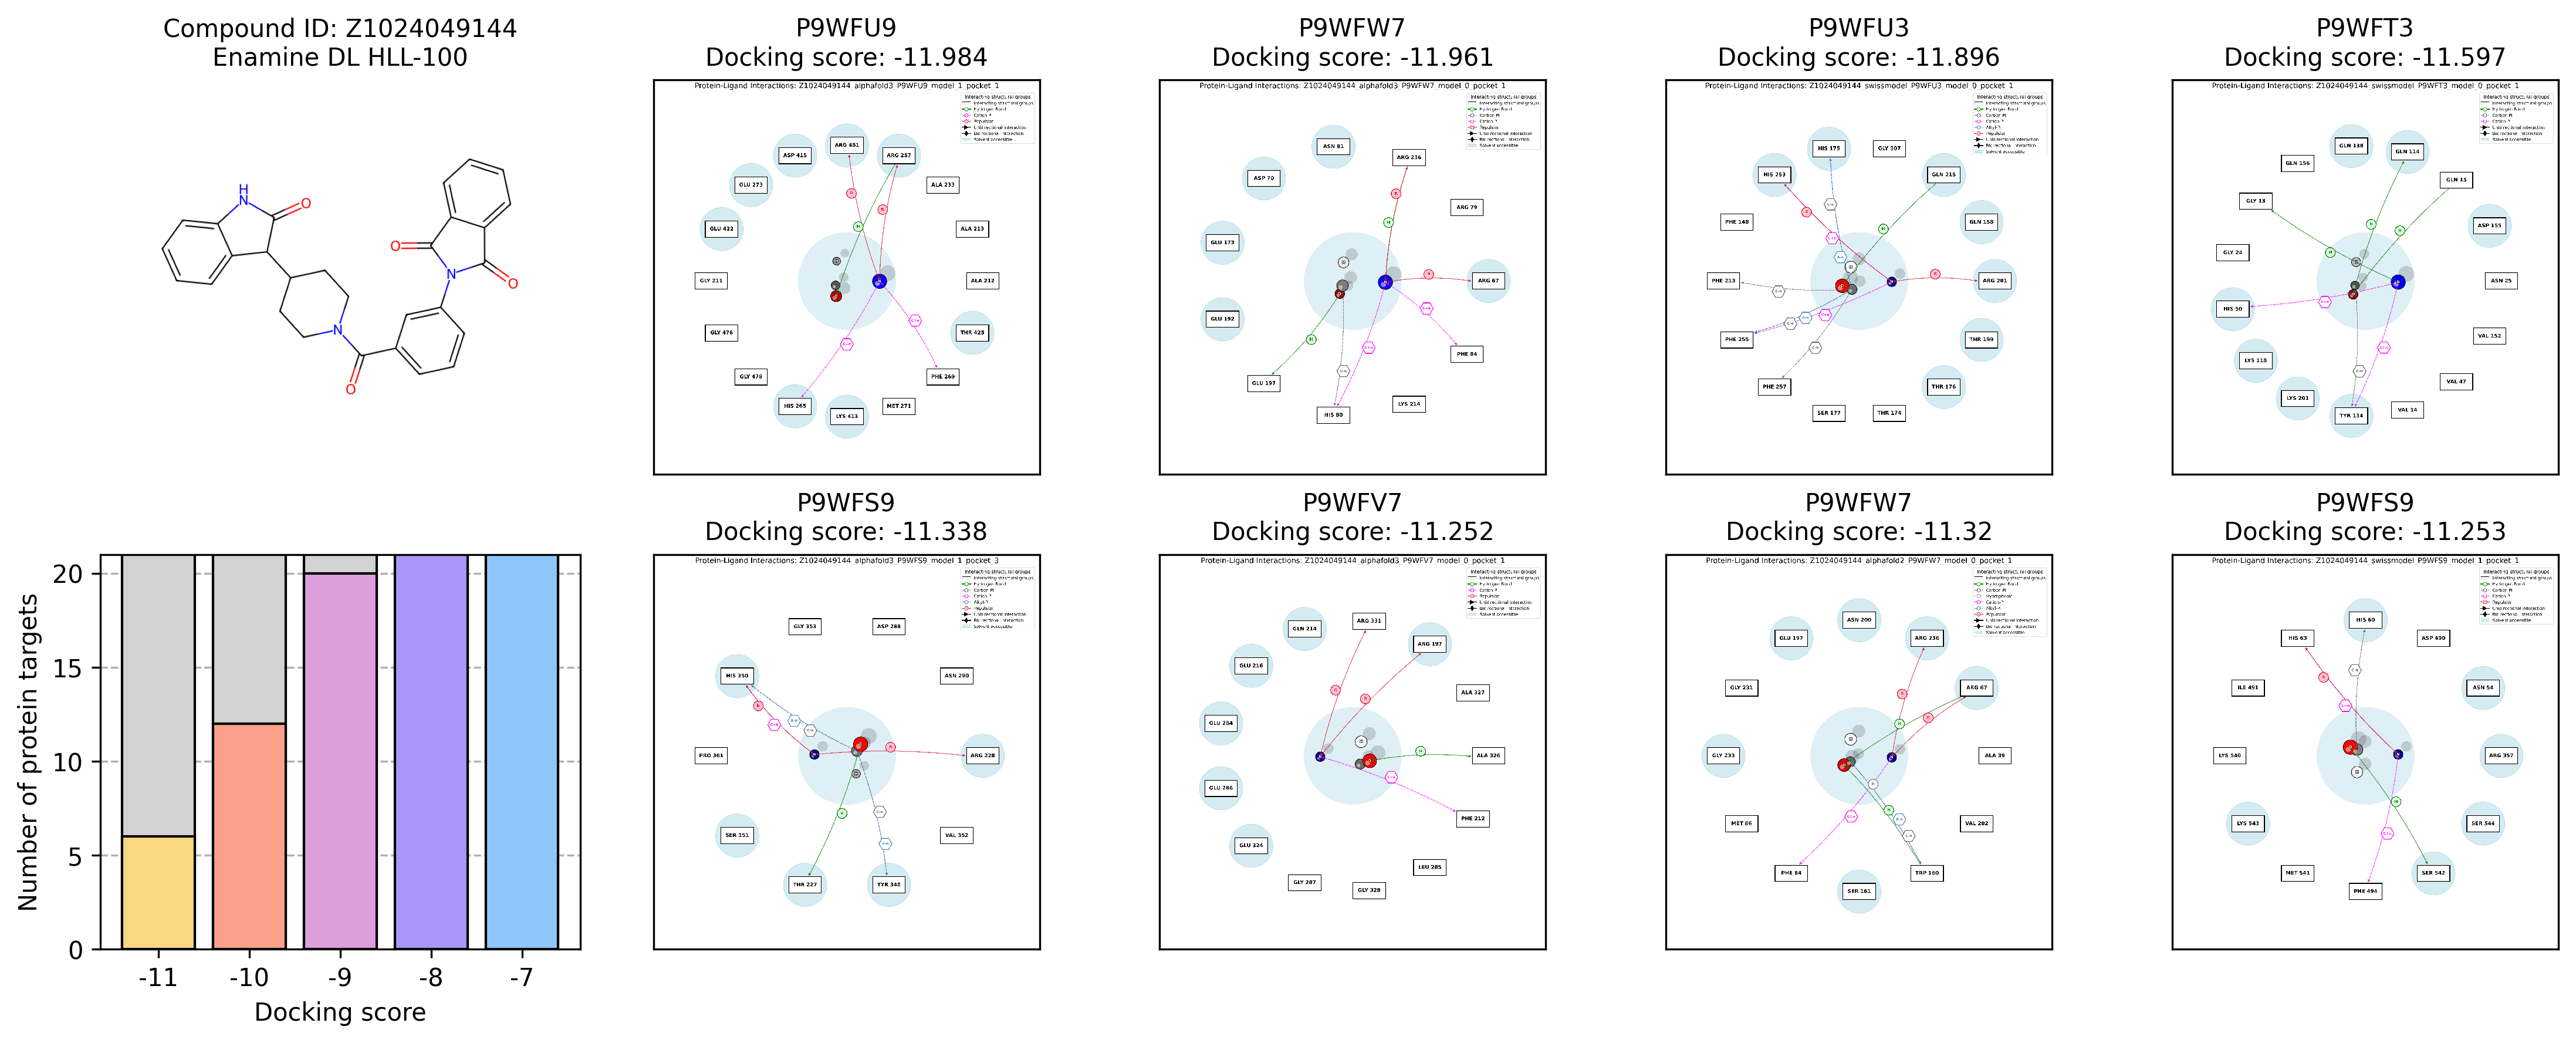

In [22]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6), dpi=300)
axes = axes.ravel()

for ax, (pocket, protein, score) in zip(axes[[1,2,3,4,6,7,8,9]], selected):
    file = os.path.join(PATH_TO_OUTPUT, COMPOUND_ID, f"{COMPOUND_ID}_{pocket}_pandamap.png")
    ax.imshow(mpimg.imread(file), interpolation='none')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"{protein}\nDocking score: {score}", fontsize=10)

ax = axes[0]
mol_img = Draw.MolToImage(mol, size=(600, 600))
ax.imshow(np.asarray(mol_img))
ax.axis("off")
ax.set_title(f"Compound ID: {COMPOUND_ID}\nEnamine DL HLL-100", fontsize=10)

ax = axes[5]
scores_to_visualize = [-11, -10, -9, -8, -7]
ax.set_xticks([i for i in range(len(scores_to_visualize))], scores_to_visualize)
ax.set_ylim([0, 21])
ax.grid(linestyle='--', zorder=-2)
ax.set_ylabel("Number of protein targets")
ax.set_xlabel("Docking score")
colors = ['#FAD782', '#FAA08B', '#DC9FDC', '#AA96FA', '#8DC7FA', '#BEE6B4']
for c, score in enumerate(scores_to_visualize):
    ax.bar(c, 21, color="#D2D2D2", edgecolor='k', zorder=2)
    ax.bar(c, len(cpd_to_proteins[score][COMPOUND_ID]), color=colors[c], edgecolor='k', zorder=2)

plt.tight_layout()
plt.show()